In [ ]:
import os
from ultralytics import YOLO, settings

# Configurar o diretório base para runs
settings.update({'runs_dir': './runs'})

# Caminho absoluto para o dataset de foices 
dataset_yaml = r"C:\projetos\aula-09-foices\notebooks\sickle-1\data.yaml"

print(f"Diretório atual de trabalho: {os.getcwd()}") # Isso ajuda a debugar!

if os.path.exists(dataset_yaml):
    print(f" Arquivo encontrado: {dataset_yaml}")
else:
    print(f" Arquivo NÃO encontrado: {dataset_yaml}. Verifique se o caminho está correto.")

Diretório atual de trabalho: C:\projetos\aula-09-foices\notebooks\sickle-1
✅ Arquivo encontrado: C:\projetos\aula-09-foices\notebooks\sickle-1\data.yaml


In [ ]:
import os
from pathlib import Path
from ultralytics import YOLO, settings

settings.update({'runs_dir': './runs'})
base_dir = r"C:\projetos\aula-09-foices\notebooks\sickle-1"
yaml_path = Path(base_dir) / "data.yaml"

# Forçaando a correção do YAML
# Apontando o 'val' para a mesma pasta do 'train' pois nao estao no test
novo_yaml = f"""
path: {base_dir}
train: train/images
val: train/images
nc: 1
names: ['sickle']
"""
yaml_path.write_text(novo_yaml.strip())
print(f"data.yaml reescrito com sucesso em: {yaml_path}")

# Carregando o modelo base
model = YOLO("yolov8n.pt") 

# Iniciando o treinamento
print("Iniciando o treinamento...")
resultados = model.train(
    data=str(yaml_path),  # Passando o caminho garantido
    epochs=5,             
    imgsz=640,          
    batch=4,            
    name="treino-foices-v1"
)

print("Treinamento finalizado com sucesso!")

✅ data.yaml reescrito com sucesso em: C:\projetos\aula-09-foices\notebooks\sickle-1\data.yaml
🚀 Dando start no treinamento...
Ultralytics 8.4.53  Python-3.11.9 torch-2.12.0+cpu CPU (12th Gen Intel Core i5-12400F)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\projetos\aula-09-foices\notebooks\sickle-1\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt,

In [ ]:
from ultralytics import YOLO

# Caminho CORRETO de acordo com a arquitetura de pastas:
caminho_modelo = r"C:\projetos\aula-09-foices\notebooks\sickle-1\runs\detect\treino-foices-v1-2\weights\best.pt"
meu_modelo = YOLO(caminho_modelo)

# Fazer a detecção em uma imagem nova
# Necessario ir ate pasta train/images, copiar o nome de uma imagem e substituir no final
imagem_teste = r"C:\projetos\aula-09-foices\notebooks\sickle-1\train\images\-4-_jpg.rf.fa6201e9f602ca3792023b465fe1a7f7.jpg" 

print("Analisando imagem...")
resultados = meu_modelo.predict(
    source=imagem_teste, 
    conf=0.5,   
    save=True,  
    show=True   
)

🔍 Analisando imagem...
WARNING Environment does not support cv2.imshow() or PIL Image.show()
OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


image 1/1 C:\projetos\aula-09-foices\notebooks\sickle-1\train\images\-4-_jpg.rf.fa6201e9f602ca3792023b465fe1a7f7.jpg: 640x640 1 sickle, 43.8ms
Speed: 18.1ms preprocess, 43.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\projetos\aula-09-foices\notebooks\sickle-1\runs\detect\predict


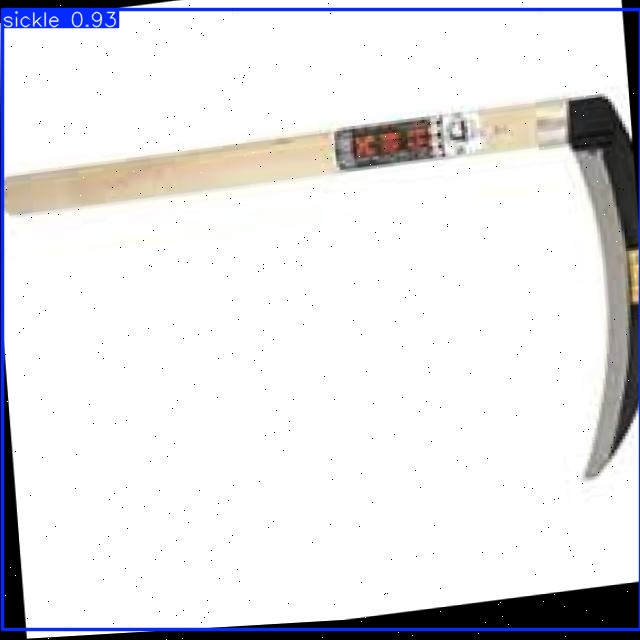

In [ ]:
from IPython.display import Image

# Substituir pelo nome do arquivo que o YOLO salvou lá na pasta runs/detect/predict
caminho_resultado = r"C:\projetos\aula-09-foices\notebooks\sickle-1\runs\detect\predict\-4-_jpg.rf.fa6201e9f602ca3792023b465fe1a7f7.jpg"

Image(filename=caminho_resultado)

In [2]:
# Detectanto em imagens

from ultralytics import YOLO

# Carregando o modelo treinado
caminho_modelo = r"C:\projetos\aula-09-foices\notebooks\sickle-1\runs\detect\treino-foices-v1-2\weights\best.pt"
meu_modelo = YOLO(caminho_modelo)

# Caminho do vídeo
# Mudar apenas o final para o nome exato do arquivo .mp4
video_entrada = r"C:\projetos\aula-09-foices\notebooks\YTDown_Shorts_Slow-Mow-scything-a-wildflower-meadow-in_Media_fWdo5F-wiy8_001_720p.mp4"

print("🎬 Processando o vídeo... Isso pode levar alguns segundos.")

# Rodando a predição no vídeo
resultados = meu_modelo.predict(
    source=video_entrada,
    conf=0.5,   # Mostra caixas com mais de 50% de certeza
    save=True   # Salva o vídeo com as marcações das foices
)

print("Vídeo processado com sucesso!")

🎬 Processando o vídeo... Isso pode levar alguns segundos.

WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1799) C:\projetos\aula-09-foices\notebooks\YTDown_Shorts_Slow-Mow-scything-a-wildflower-meadow-in_Media_fWdo5F-wiy8_001_720p.mp4: 640x384 1 sickle, 26.5ms
video 1/1 (frame 2/1799) C:\projetos\aula-09-foices\notebooks\YTDown_Shorts_Slow-Mow-scything-a-wildflower-meadow-in_Media_fWdo5F-wiy8_001_720p.mp4: 640x384 2 sickles, 25.1ms
video 1/1 (frame 3/1799) C:\projetos\aula-09-foices\no